In [73]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import glob
from sklearn.metrics import mean_squared_error
# from sklearn.linear_model import LinearRegreossion
import statsmodels.api as sm
from learners_reg import Net
import torch_linear

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [74]:
n = 100

def draw_x(n):
    # Generate n datapoints, uniform between -1 and 1
    return -1 + 2 * np.random.rand(n)

def reward(x, a = 1, c = 0.5):
    # Reward is 0 if a = 0 and is quadratic if a = 1
    return a*(x + c * x**2)

def fit_model_mse(x,r):
    # Pass in (x,r) pairs for datapoints where a = 1
    #X = x.reshape(-1, 1)  # Reshape to column vector
    #model = LinearRegression()
    #model.fit(X, r)

    #theta0 = model.intercept_
    #theta1 = model.coef_[0]
    model = sm.OLS(r, sm.add_constant(x))
    results = model.fit()

    return results.params # intercept, slope

def fit_model_esr(x,r, alpha = 0, k = 5, num_epochs = 100, verbose = False):

    model = torch_linear.LinearRegression()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

    for epoch in range(num_epochs):
        # Forward pass
        r_pred = model(x)
        loss = torch_linear.esr(r_pred, r, alpha = alpha, k = k)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if verbose:
            if epoch % 50 == 0:
                print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f}")

    # -----------------------
    # Learned parameters
    # -----------------------
    return model.linear.bias.item(), model.linear.weight.item()




Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
[0.04523725 1.13010177]


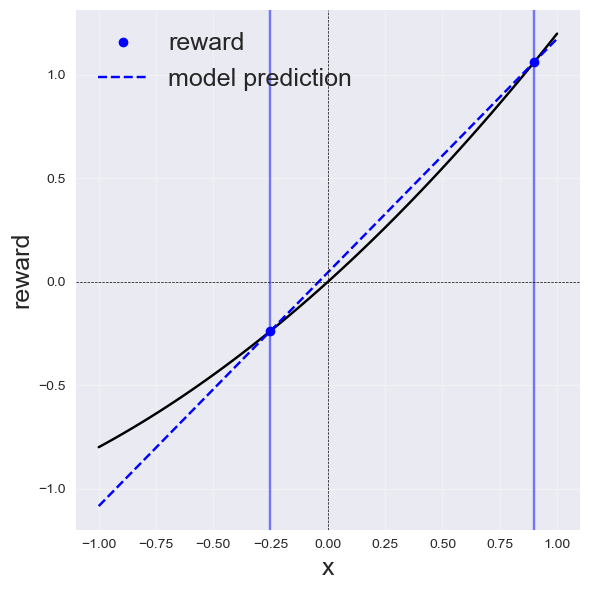

In [77]:
c = 0.2
np.random.seed(42)
n = 2

# Generate data
x = draw_x(n)
r = reward(x,c=c)
theta_hat_mse = fit_model_mse(x,r)
print(theta_hat_mse)

# Plot of x + cx^2 vs x
# _x and _r are x
_x = np.linspace(-1, 1, 100)
r_true = reward(_x,c=c)

r_hat_mse = theta_hat_mse[0] + theta_hat_mse[1]*_x

# Find the largest point in x that is below 0 
L = np.max(x[x<0])
U = np.min(x[x>0])



plt.figure(figsize=(6, 6))
plt.plot(_x, r_true, 'k-')
plt.plot(x, r, 'bo',label='reward')
plt.plot(_x, r_hat_mse, 'b--',label='model prediction')

plt.axvline(L,alpha=0.5,color='b')
plt.axvline(U,alpha=0.5,color='b')

plt.xlabel('x', fontsize=18)
plt.ylabel('reward', fontsize=18)
# plt.title('Plot of x + cx² vs x', fontsize=14, fontweight='bold')
# plt.legend(['reward', 'model prediction'],loc='best')
plt.legend(fontsize=18)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
plt.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
plt.tight_layout()
# plt.savefig('plot_quadratic.png', dpi=150, bbox_inches='tight')
plt.show()

In [98]:

def get_expected_reward(thresh, c):
    _x = np.linspace(-1, 1, 100)
    return reward(_x[_x > thresh], c=c).sum() / len(_x)


def run_one_xp(n,c,seed):

    np.random.seed(seed)
    x = draw_x(n)
    x_tensor = torch.unsqueeze(torch.tensor(x), -1)
    r = reward(x_tensor,c=c)

    # run MSE
    theta_hat_mse = fit_model_esr(x_tensor, r)
    thresh_mse = -theta_hat_mse[0] / theta_hat_mse[1]

    # run ESR
    theta_hat_esr = fit_model_esr(x_tensor, r, alpha = 1, k = 1)
    thresh_esr = -theta_hat_esr[0] / theta_hat_esr[1]

    # run mix
    theta_hat_mix = fit_model_esr(x_tensor, r, alpha = 0.5, k = 1)
    thresh_mix = -theta_hat_mix[0] / theta_hat_mix[1]


    expected_reward_mse = get_expected_reward(thresh_mse, c)
    expected_reward_esr = get_expected_reward(thresh_esr, c)
    expected_reward_mix = get_expected_reward(thresh_mix, c)

    return expected_reward_mse, expected_reward_esr, expected_reward_mix

def run_xp(n,c,n_reps=10):

    mse = []
    esr = []
    mix = []

    for seed in range(n_reps):
        _mse, _esr, _mix = run_one_xp(n,c,seed)
        mse.append(_mse)
        esr.append(_esr)
        mix.append(_mix)

    return np.mean(mse), np.std(mse)/np.sqrt(n_reps), np.mean(esr), np.std(esr)/np.sqrt(n_reps), np.mean(mix), np.std(mix)/np.sqrt(n_reps)






In [99]:
df = pd.DataFrame(columns=['n', 'c', 'mse', 'mse_stderr', 'esr', 'esr_stderr', 'mix', 'mix_stderr'])

c = 0.2
for n in [2,4,8,16,32,64,128, 256, 512, 1024]:
    mse, mse_stderr, esr, esr_stderr, mix, mix_stderr = run_xp(n,c)
    df.loc[len(df)] = [n,c,mse,mse_stderr,esr,esr_stderr, mix, mix_stderr]

In [101]:
c = 0.4
for n in [2,4,8,16,32,64,128, 256, 512, 1024]:
    mse, mse_stderr, esr, esr_stderr, mix, mix_stderr = run_xp(n,c)
    df.loc[len(df)] = [n,c,mse,mse_stderr,esr,esr_stderr, mix, mix_stderr]

In [102]:
df

,n,c,mse,mse_stderr,esr,esr_stderr,mix,mix_stderr
0,2.0,0.2,0.285239,0.000348,0.121460,3.339768e-02,0.241421,0.026863
1,4.0,0.2,0.257269,0.027120,0.127186,3.404378e-02,0.261943,0.017620
2,8.0,0.2,0.284433,0.001130,0.194781,3.425229e-02,0.263482,0.007790
3,16.0,0.2,0.285671,0.000145,0.281997,1.479396e-03,0.285664,0.000193
4,32.0,0.2,0.285471,0.000121,0.285356,3.725463e-04,0.286130,0.000092
5,64.0,0.2,0.285610,0.000086,0.286391,4.307743e-05,0.286341,0.000044
6,128.0,0.2,0.285491,0.000088,0.286411,4.670119e-05,0.286311,0.000047
7,256.0,0.2,0.285560,0.000066,0.286462,3.774506e-05,0.286341,0.000044
8,512.0,0.2,0.285630,0.000000,0.286522,9.563301e-06,0.286492,0.000016
9,1024.0,0.2,0.285630,0.000000,0.286532,1.755417e-17,0.286472,0.000016


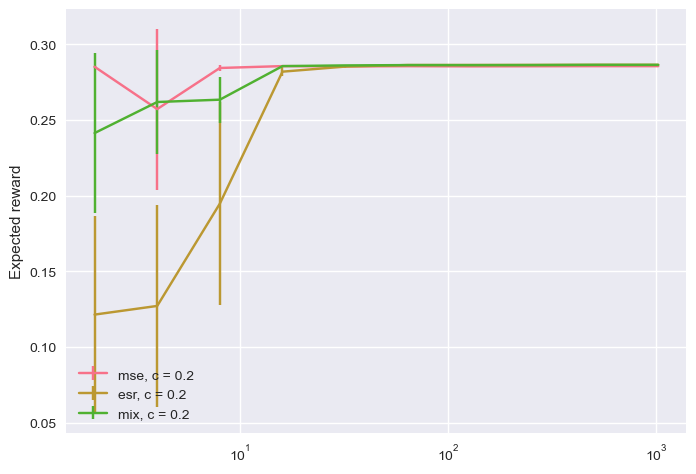

In [105]:
plt.errorbar(df[df['c'] == 0.2]['n'],df[df['c'] == 0.2]['mse'],1.96*df[df['c'] == 0.2]['mse_stderr'],label='mse, c = 0.2')
plt.errorbar(df[df['c'] == 0.2]['n'],df[df['c'] == 0.2]['esr'],1.96*df[df['c'] == 0.2]['esr_stderr'],label='esr, c = 0.2')
plt.errorbar(df[df['c'] == 0.2]['n'],df[df['c'] == 0.2]['mix'],1.96*df[df['c'] == 0.2]['mix_stderr'],label='mix, c = 0.2')
# plt.errorbar(df[df['c'] == 0.4]['n'],df[df['c'] == 0.4]['mse'],1.96*df[df['c'] == 0.4]['mse_stderr'],label='mse, c = 0.4')
# plt.errorbar(df[df['c'] == 0.4]['n'],df[df['c'] == 0.4]['esr'],1.96*df[df['c'] == 0.4]['esr_stderr'],label='esr, c = 0.4')
# plt.errorbar(df[df['c'] == 0.4]['n'],df[df['c'] == 0.4]['mix'],1.96*df[df['c'] == 0.4]['mix_stderr'],label='mix, c = 0.4')
plt.legend(loc='best')
plt.ylabel('Expected reward')
plt.xlabel('')
plt.xscale('log')

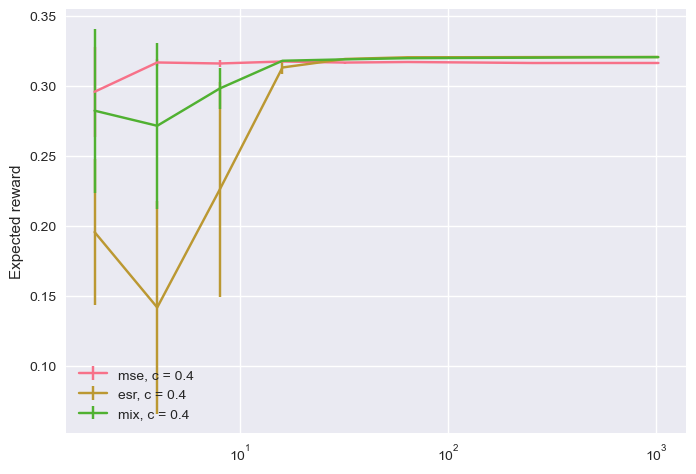

In [106]:
# plt.errorbar(df[df['c'] == 0.2]['n'],df[df['c'] == 0.2]['mse'],1.96*df[df['c'] == 0.2]['mse_stderr'],label='mse, c = 0.2')
# plt.errorbar(df[df['c'] == 0.2]['n'],df[df['c'] == 0.2]['esr'],1.96*df[df['c'] == 0.2]['esr_stderr'],label='esr, c = 0.2')
# plt.errorbar(df[df['c'] == 0.2]['n'],df[df['c'] == 0.2]['mix'],1.96*df[df['c'] == 0.2]['mix_stderr'],label='mix, c = 0.2')
plt.errorbar(df[df['c'] == 0.4]['n'],df[df['c'] == 0.4]['mse'],1.96*df[df['c'] == 0.4]['mse_stderr'],label='mse, c = 0.4')
plt.errorbar(df[df['c'] == 0.4]['n'],df[df['c'] == 0.4]['esr'],1.96*df[df['c'] == 0.4]['esr_stderr'],label='esr, c = 0.4')
plt.errorbar(df[df['c'] == 0.4]['n'],df[df['c'] == 0.4]['mix'],1.96*df[df['c'] == 0.4]['mix_stderr'],label='mix, c = 0.4')
plt.legend(loc='best')
plt.ylabel('Expected reward')
plt.xlabel('')
plt.xscale('log')

In [87]:
plt.close()